In [1]:
import os
from copy import deepcopy
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation
import numpy as np

# Imports from PyTorch.
import torch
from torch import nn
from torchvision import datasets, transforms
from torch import nn, Tensor
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch import max as torch_max

import sys


# Imports from aihwkit.
from aihwkit.nn import AnalogConv2d, AnalogLinear, AnalogSequential
from aihwkit.simulator.presets import StandardHWATrainingPreset
from aihwkit.optim import AnalogSGD
from aihwkit.nn.conversion import convert_to_analog, convert_to_digital
from aihwkit.simulator.configs import (
    SingleRPUConfig,
    FloatingPointRPUConfig,
    ConstantStepDevice,
    FloatingPointDevice,
)

from aihwkit.simulator.parameters import (
    WeightQuantizerParameter,
)
from aihwkit.simulator.parameters.enums import WeightQuantizerType

from aihwkit.simulator.rpu_base import cuda

src = os.getcwd()
src = os.path.abspath(os.path.join(src, '/../src'))
sys.path.append(src)

# Check device
USE_CUDA = 0
if cuda.is_compiled():
    USE_CUDA = 1

if USE_CUDA:
    torch.cuda.set_device(0)
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")
print("Device: ", DEVICE)


cur_dir = os.getcwd()
print("Current directory: ", cur_dir)


DUMP_DIR = os.path.join('/home/ecabiati/storage/inference_results')


Device:  cuda:0
Current directory:  /home/ecabiati/cellar/aihwkit/sandbox/cuda


## Definition of the RPU_CONFIGs with different calibrations
---
At this stage, the base RPU-configuration object is an ideal <code>FloatingPointRPUConfig</code> object, that is used to model a <i>floating-point device</i> (implements ideal devices forward/backward/update behavior).
This differs from the <code>InferenceRPUConfig</code>, that is used to model inference on real analog device (training is done in hardware-aware manner, thus using only the non-idealities of the forward-pass, but backward and update passes are ideal), or the <code>SingleRPUConfig</code>, that is the configuration for an analog (pulsed device) resistive processing unit ( update and backward passes are non-ideal). \
The only difference among the defined RPU_CONFIGs is the <code>quantization</code> field

In [2]:
LEVELS = [3, 5, 9, 17, 33]
RPU_CONFIG_BASE = FloatingPointRPUConfig() # Ideal device


# - - -  PERCENTILE  - - -
# We will also try different percentile values for each model.
RPU_CONFIG_PERCENTILE = deepcopy(RPU_CONFIG_BASE)
EPS = [0.03, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175]
RPU_CONFIG_PERCENTILE.quantization = WeightQuantizerParameter(
        eps= EPS[0],
        levels = LEVELS[0],
        method = "percentile",
        # amax_channelwise=True
    )
# - - -  ABS MAX  - - -
RPU_CONFIG_MAX = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_MAX.quantization = WeightQuantizerParameter(
        levels = LEVELS[0],
        method = "max",
        # amax_channelwise=True
    )

# - - -  MSE - - -
RPU_CONFIG_MSE = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_MSE.quantization = WeightQuantizerParameter(
        eps= EPS[0],
        levels = LEVELS[0],
        method = "mse",
        # amax_channelwise=True
    )

# from torchvision.datasets.utils import download_url
# download_url(
#     "https://aihwkit-tutorial.s3.us-east.cloud-object-storage.appdomain.cloud/resnet9s.th",
#     "../resnet/resnet9s.th",
# )

## Benchmarking the calibrations
---
We now compare the different approaches using 3 different models - LeNet5, VGG8, ResNet9s - on 3 different datasets respectively - MNIST, SVHN, CIFAR10. The models are pretrained using the <code>FloatingPointRPUConfig</code>, imported and the quantized using the different calibrations. Inference is then performed on the quantized models and the accuracy is recorded. The results are then compared. We also repeat the same measurements using the non idealities of the IRPS paper.

##  <b>1. LeNet5</b> :

In [4]:
# SEED = 1
# N_EPOCHS = 20
BATCH_SIZE = 128
# LEARNING_RATE = 0.01
N_CLASSES = 10
# Path to store MNIST dataset
PATH_DATASET = cur_dir + "/../data/mnist"

def load_images():
    """Load images for train from torchvision datasets."""

    transform = transforms.Compose([transforms.ToTensor()])
    train_set = datasets.MNIST(PATH_DATASET, download=True, train=True, transform=transform)
    val_set = datasets.MNIST(PATH_DATASET, download=True, train=False, transform=transform)
    train_data = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_analog_network(RPU_CONFIG):
    """Return a LeNet5 inspired analog model."""
    channel = [16, 32, 512, 128]
    model = AnalogSequential(
        AnalogConv2d(
            in_channels=1, out_channels=channel[0], kernel_size=5, stride=1, rpu_config=RPU_CONFIG
        ),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[1],
            kernel_size=5,
            stride=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2),
        nn.Tanh(),
        nn.Flatten(),
        AnalogLinear(in_features=channel[2], out_features=channel[3], rpu_config=RPU_CONFIG),
        nn.Tanh(),
        AnalogLinear(in_features=channel[3], out_features=N_CLASSES, rpu_config=RPU_CONFIG),
        nn.LogSoftmax(dim=1),
    )

    return model

def test_evaluation(validation_data, model, criterion):
    """Test trained network.

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float:  model, loss, error, and accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


In [4]:
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

# Standard (unquantized) model
rpu_config = RPU_CONFIG_BASE
# RESULTS_NON_QUANTIZED = cur_dir + "/lenet5_results"
RESULTS_NON_QUANTIZED = "/home/ecabiati/storage/lenet5_models/lenet5_from_scratch_results"


state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "LeNet5.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = create_analog_network(rpu_config).to(DEVICE)
        model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
        model.eval()
        quantized_model = convert_to_analog(model, rpu_config)

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    model.eval()
    quantized_model = convert_to_analog(model, rpu_config)

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    model.eval()
    quantized_model = convert_to_analog(model, rpu_config)

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_lenet5.th"))

Accuracy of the non-quantized model: 98.82%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 97.01%
Accuracy of the percentile model with eps=0.030 and levels=5: 98.61%
Accuracy of the percentile model with eps=0.030 and levels=9: 98.61%
Accuracy of the percentile model with eps=0.030 and levels=17: 98.71%
Accuracy of the percentile model with eps=0.030 and levels=33: 98.74%
Accuracy of the percentile model with eps=0.050 and levels=3: 97.48%
Accuracy of the percentile model with eps=0.050 and levels=5: 98.51%
Accuracy of the percentile model with eps=0.050 and levels=9: 98.61%
Accuracy of the percentile model with eps=0.050 and levels=17: 98.70%
Accuracy of the percentile model with eps=0.050 and levels=33: 98.65%
Accuracy of the percentile model with eps=0.075 and levels=3: 97.90%
Accuracy of the percentile model with eps=0.075 and levels=5: 98.55%
Accuracy of the percentile model with eps=0.075 and levels=9: 98.

In [5]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_lenet5.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile = results["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index = mean_accuracy_percentile.argmax()
best_eps = EPS[best_eps_index]
print(f"Best eps: {best_eps}")

Best eps: 0.075


In [9]:
def heatmap(data, row_labels, col_labels, ax = None,
            cbar_kw = {}, cbarlabel = "", title = "", **kwargs):

    if not ax:
      ax = plt.gca()

    # im = ax.imshow(data, **kwargs)
    im = ax.imshow(data, **kwargs, vmin=0, vmax=100)
    # ax.set_title(title, fontdict={"fontsize": 14}, y = -0.075)

    cbar = ax.figure.colorbar(im, ax = ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation = 90, va = "bottom",fontdict = {"fontsize": 20}, labelpad = 25)

    ax.set_xticks(np.arange(data.shape[1]), labels = col_labels)
    ax.set_yticks(np.arange(data.shape[0]), labels = row_labels)

    ax.tick_params(top = True, bottom = False,
                   labeltop = True, labelbottom = False)

    plt.setp(ax.get_xticklabels(), rotation = -30, ha = "right",
             rotation_mode = "anchor")

    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor = True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor = True)
    # increase the size of the ticks
    ax.tick_params(axis = "both", which = "both", length = 4, width = 2)
    ax.grid(which = "minor", color = "k", linestyle = '-', linewidth = 4, zorder = 3)
    y_ticks = np.arange(data.shape[0] + 1) - 0.5
    x_ticks = np.arange(data.shape[1] + 1) - 0.5
    for y in y_ticks:
        ax.axhline(y=y, color='w', linewidth=3, zorder=3)
    for x in x_ticks:
        ax.axvline(x=x, color='w', linewidth=3, zorder=3)
    ax.tick_params(which =  "minor", bottom = False, left = False)

    return im, cbar


def annotate_heatmap(im, data = None, valfmt="{x:.2f}",
                     textcolors = ("black", "white"),
                     threshold = None, **textkw):

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    kw = dict(horizontalalignment = "center",
              verticalalignment = "center",
              fontsize = 14)
    kw.update(textkw)

    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) < threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

[73.79 98.41 98.33 98.76 98.79]
[97.82 98.58 98.65 98.76 98.76]
[97.9  98.55 98.55 98.59 98.63]


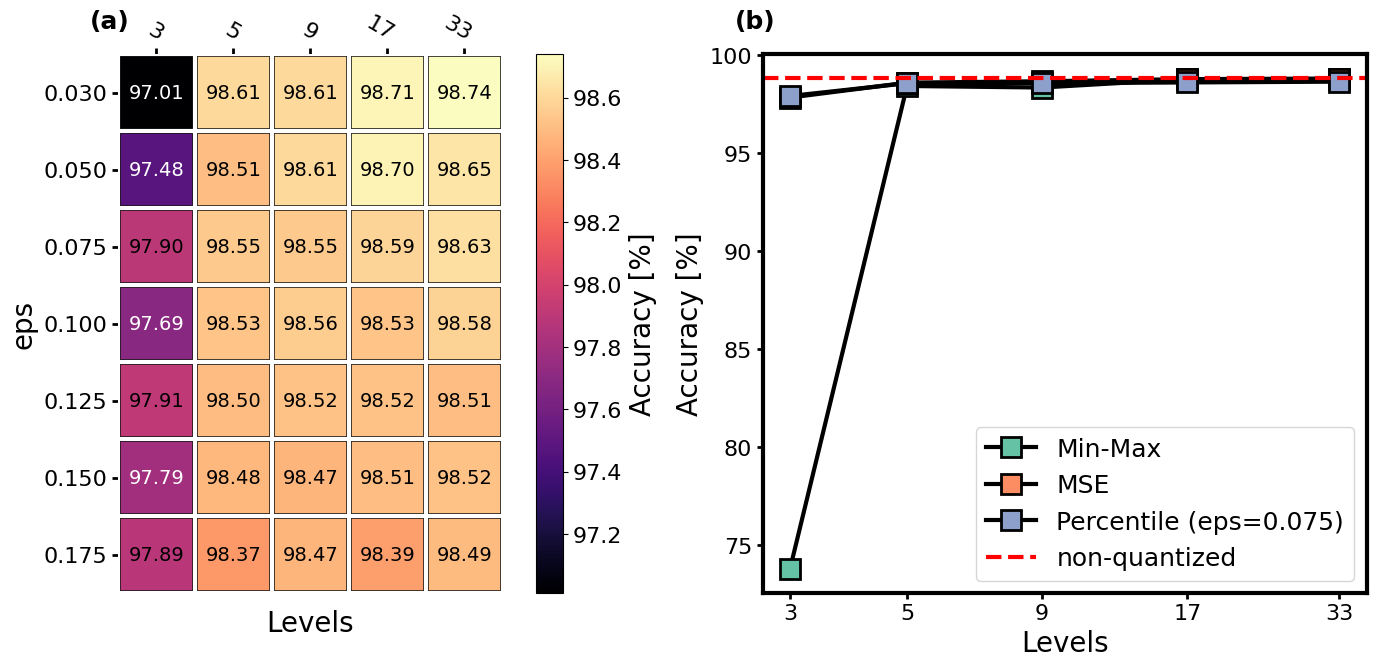

In [6]:


# =========================================================================================

fig, axs = plt.subplot_mosaic([["heatmap", "comparison"]], figsize=(18, 7), gridspec_kw={"width_ratios": [1.1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs["heatmap"], cmap = "magma", aspect = "equal", cbarlabel = "Accuracy [%]", title = "Percentile calibration")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")
cbar.ax.tick_params(labelsize = 16)

# add x and y labels
axs["heatmap"].set_xlabel("Levels", fontdict = {"fontsize": 20})
axs["heatmap"].set_ylabel("eps", fontdict = {"fontsize": 20})

# The second plot shows the comparison between the different calibration methods
data = np.array([ results["max"], results["mse"], results["percentile"][best_eps_index, :]])
x = LEVELS
print(data[0])
print(data[1])
print(data[2])

colors = matplotlib.colormaps["Set2"].colors
axs["comparison"].plot(x, data[0], label = "Min-Max", marker = "s", markerfacecolor = colors[0], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)
axs["comparison"].plot(x, data[1], label = "MSE", marker = "s", markerfacecolor = colors[1], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)
axs["comparison"].plot(x, data[2], label = f"Percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)

axs["comparison"].set_xscale("log", base = 2)
axs["comparison"].set_xticks(x)
axs["comparison"].set_xticklabels([str(levels) for levels in x])

# axs["comparison"].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
#increase the size of the ticks
axs["comparison"].tick_params(axis = "both", which = "both", length = 4, width = 3)
axs["comparison"].axhline(y = results["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 3)


# axs["comparison"].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
# axs["comparison"].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs["comparison"].legend()
axs["comparison"].set_xlabel("Levels", fontdict = {"fontsize": 20})
axs["comparison"].set_ylabel("Accuracy [%]", fontdict = {"fontsize": 20})
# axs["comparison"].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})

# increase the ticks label size
axs["heatmap"].tick_params(axis = "both", which = "major", labelsize = 16)
axs["comparison"].tick_params(axis = "both", which = "major", labelsize = 16)
# make the axis border for the second plot thicker
axs["comparison"].spines["top"].set_linewidth(3)
axs["comparison"].spines["right"].set_linewidth(3)
axs["comparison"].spines["bottom"].set_linewidth(3)
axs["comparison"].spines["left"].set_linewidth(3)
# increase the thickness of the ticks
axs["comparison"].tick_params(width = 2)
axs["heatmap"].tick_params(width = 2)

# make the legend bigger
axs["comparison"].legend(fontsize = 18)

# set a and b labels
for label, ax in axs.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    ax.text(
        0.0, 1.0, "(a)" if label=="heatmap" else "(b)", transform=(
            ax.transAxes + ScaledTranslation(-20/72, 15/72, fig.dpi_scale_trans)),
        fontsize=18, va='bottom', fontweight='bold')

# plt.tight_layout()


## <b>2. VGG8</b> :

In [14]:
# SEED = 1
# N_EPOCHS = 20
BATCH_SIZE = 128
# LEARNING_RATE = 0.1
N_CLASSES = 10
PATH_DATASET = cur_dir + "/../data/svhn"

# RPU_CONFIG.runtime.offload_gradient = True
# RPU_CONFIG.runtime.offload_input = True


def load_images():
    """Load images for train from torchvision datasets."""
    mean = Tensor([0.4377, 0.4438, 0.4728])
    std = Tensor([0.1980, 0.2010, 0.1970])

    print(f"Normalization data: ({mean},{std})")

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
    train_set = datasets.SVHN(PATH_DATASET, download=True, split="train", transform=transform)
    val_set = datasets.SVHN(PATH_DATASET, download=True, split="test", transform=transform)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_analog_network(RPU_CONFIG):
    """Create a Vgg8 inspired analog model.

    Returns:
       nn.Module: VGG8 model
    """
    channel_base = 48
    channel = [channel_base, 2 * channel_base, 3 * channel_base]
    fc_size = 8 * channel_base
    model = AnalogSequential(
        AnalogConv2d(in_channels=3, out_channels=channel[0], kernel_size=3, stride=1, padding=1, rpu_config=RPU_CONFIG),
        nn.ReLU(),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[0],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.BatchNorm2d(channel[0]),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[1],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.ReLU(),
        AnalogConv2d(
            in_channels=channel[1],
            out_channels=channel[1],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.BatchNorm2d(channel[1]),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1),
        AnalogConv2d(
            in_channels=channel[1],
            out_channels=channel[2],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.ReLU(),
        AnalogConv2d(
            in_channels=channel[2],
            out_channels=channel[2],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.BatchNorm2d(channel[2]),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1),
        nn.Flatten(),
        AnalogLinear(in_features=16 * channel[2], out_features=fc_size, rpu_config=RPU_CONFIG),
        nn.ReLU(),
        AnalogLinear(in_features=fc_size, out_features=N_CLASSES, rpu_config=RPU_CONFIG),
        nn.LogSoftmax(dim=1),
    )
    return model

def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy

In [ ]:
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()
rpu_config = FloatingPointRPUConfig()

# Standard model
RESULTS_NON_QUANTIZED = "/home/ecabiati/storage/vgg8_models/vgg8_results"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "vgg8.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = create_analog_network(rpu_config).to(DEVICE)
        model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
        quantized_model = convert_to_analog(model, rpu_config)
        quantized_model.eval()

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_vgg8.th"))



Normalization data: (tensor([0.4377, 0.4438, 0.4728]),tensor([0.1980, 0.2010, 0.1970]))
Using downloaded and verified file: /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/svhn/train_32x32.mat
Using downloaded and verified file: /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/svhn/test_32x32.mat
Accuracy of the non-quantized model: 94.89%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 78.97%
Accuracy of the percentile model with eps=0.030 and levels=5: 89.19%
Accuracy of the percentile model with eps=0.030 and levels=9: 93.04%
Accuracy of the percentile model with eps=0.030 and levels=17: 92.88%
Accuracy of the percentile model with eps=0.030 and levels=33: 93.29%
Accuracy of the percentile model with eps=0.050 and levels=3: 83.67%
Accuracy of the percentile model with eps=0.050 and levels=5: 90.78%
Accuracy of the percentile model with eps=0.050 and levels=9: 92.07%
Accuracy of the percentile model with ep

In [7]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_vgg8.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile = results["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index = mean_accuracy_percentile.argmax()
best_eps = EPS[best_eps_index]
print(f"Best eps: {best_eps}")

Best eps: 0.05


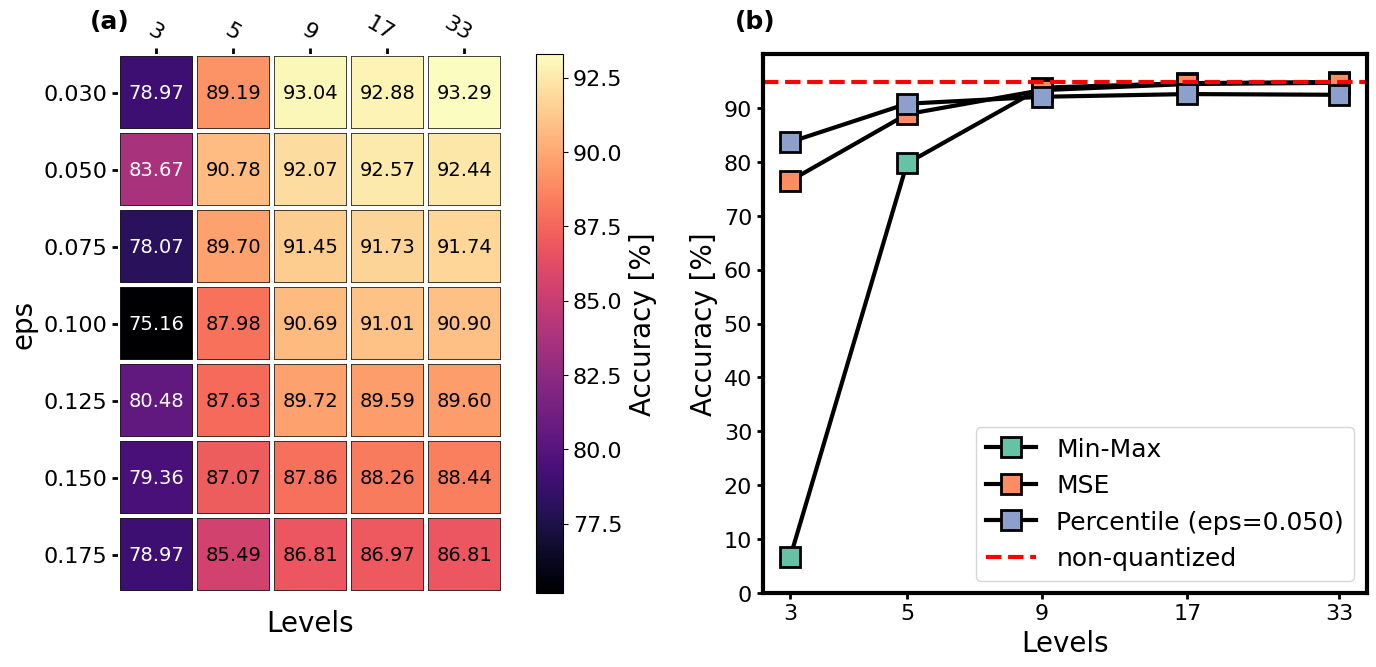

In [8]:
# =========================================================================================

fig, axs = plt.subplot_mosaic([["heatmap", "comparison"]], figsize=(18, 7), gridspec_kw={"width_ratios": [1.1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs["heatmap"], cmap = "magma", aspect = "equal", cbarlabel = "Accuracy [%]", title = "Percentile calibration")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")
cbar.ax.tick_params(labelsize = 16)
# add x and y labels
axs["heatmap"].set_xlabel("Levels", fontdict = {"fontsize": 20})
axs["heatmap"].set_ylabel("eps", fontdict = {"fontsize": 20})

# The second plot shows the comparison between the different calibration methods
data = np.array([ results["max"], results["mse"], results["percentile"][best_eps_index, :]])
x = LEVELS


colors = matplotlib.colormaps["Set2"].colors
axs["comparison"].plot(x, data[0], label = "Min-Max", marker = "s", markerfacecolor = colors[0], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)
axs["comparison"].plot(x, data[1], label = "MSE", marker = "s", markerfacecolor = colors[1], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)
axs["comparison"].plot(x, data[2], label = f"Percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)

axs["comparison"].set_xscale("log", base = 2)
axs["comparison"].set_xticks(x)
axs["comparison"].set_xticklabels([str(levels) for levels in x])
axs["comparison"].set_yticks(np.arange(0, 100 , 10.0))
axs["comparison"].set_ylim(0, 100)

# axs["comparison"].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
#increase the size of the ticks
axs["comparison"].tick_params(axis = "both", which = "both", length = 4, width = 3)
axs["comparison"].axhline(y = results["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 3)
# set multiple scale for the y axis



# axs["comparison"].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
# axs["comparison"].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs["comparison"].legend()
axs["comparison"].set_xlabel("Levels", fontdict = {"fontsize": 20})
axs["comparison"].set_ylabel("Accuracy [%]", fontdict = {"fontsize": 20})
# axs["comparison"].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})

# increase the ticks label size
axs["heatmap"].tick_params(axis = "both", which = "major", labelsize = 16)
axs["comparison"].tick_params(axis = "both", which = "major", labelsize = 16)
# make the axis border for the second plot thicker
axs["comparison"].spines["top"].set_linewidth(3)
axs["comparison"].spines["right"].set_linewidth(3)
axs["comparison"].spines["bottom"].set_linewidth(3)
axs["comparison"].spines["left"].set_linewidth(3)
# increase the thickness of the ticks
axs["comparison"].tick_params(width = 2)
axs["heatmap"].tick_params(width = 2)

# make the legend bigger
axs["comparison"].legend(fontsize = 18)

# set a and b labels
for label, ax in axs.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    ax.text(
        0.0, 1.0, "(a)" if label=="heatmap" else "(b)", transform=(
            ax.transAxes + ScaledTranslation(-20/72, 15/72, fig.dpi_scale_trans)),
        fontsize=18, va='bottom', fontweight='bold')
 

## <b>3. ResNet9s</b> :

In [11]:
# SEED = 1
# N_EPOCHS = 40
BATCH_SIZE = 64
# LEARNING_RATE = 0.01
N_CLASSES = 10
PATH_DATASET = cur_dir + "/../data/cifar10"

import torchvision

class TorchCutout(object):
    def __init__(self, length, fill=(0.0, 0.0, 0.0)):
        self.length = length
        self.fill = torch.tensor(fill).reshape(shape=(3, 1, 1))

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)
        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)
        img[:, y1:y2, x1:x2] = self.fill
        return img

def load_images():
    transform_train = transforms.Compose(
        [
            torchvision.transforms.RandomCrop(32, padding=4),
            torchvision.transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), 
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010)
            ),
            TorchCutout(length=8)
            ])
    
    transform_test = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
            ),
        ]
    )

    train_set = datasets.CIFAR10(PATH_DATASET, train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10(PATH_DATASET, train=False, download=True, transform=transform_test)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data

class LambdaLayer(torch.nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(torch.nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option="A", RPU_CONFIG=None):
        super(BasicBlock, self).__init__()
        self.conv1 = AnalogConv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn1 = torch.nn.BatchNorm2d(planes)
        self.conv2 = AnalogConv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn2 = torch.nn.BatchNorm2d(planes)

        self.shortcut = AnalogSequential()
        if stride != 1 or in_planes != planes:
            if option == "A":
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(
                        x[:, :, ::2, ::2],
                        (0, 0, 0, 0, planes // 4, planes // 4),
                        "constant",
                        0,
                    )
                )
            elif option == "B":
                self.shortcut = AnalogSequential(
                    AnalogConv2d(
                        in_planes,
                        self.expansion * planes,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                        rpu_config=RPU_CONFIG,
                    ),
                    torch.nn.BatchNorm2d(self.expansion * planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


def Resnet9(channels, RPU_CONFIG, first_layer_quantization = True):
    """
    From https://github.com/matthias-wright/cifar10-resnet/
    """

    # resnet9 [56,112,224,224]
    # resnet9s [28,28,28,56]

    FIRST_LAYER_RPU_CONFIG = deepcopy(RPU_CONFIG)
    if first_layer_quantization == False:
        FIRST_LAYER_RPU_CONFIG.quantization = WeightQuantizerParameter(
            quantizer_type=WeightQuantizerType.NONE
        )

        print("No quantization for the first layer has been requested.")
        print("First layer RPU_CONFIG: ", FIRST_LAYER_RPU_CONFIG.quantization)
        print("Original RPU_CONFIG quantization parameter: ", RPU_CONFIG.quantization)


    model = AnalogSequential(
        # prep
        AnalogConv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=FIRST_LAYER_RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[0], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        # Layer 1
        AnalogConv2d(
            in_channels=channels[0],
            out_channels=channels[1],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[1], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[1], planes=channels[1], stride=1, RPU_CONFIG=RPU_CONFIG),
        # Layer 2
        AnalogConv2d(
            in_channels=channels[1],
            out_channels=channels[2],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[2], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 3
        AnalogConv2d(
            in_channels=channels[2],
            out_channels=channels[3],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[3], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[3], planes=channels[3], stride=1, RPU_CONFIG=RPU_CONFIG),
        torch.nn.MaxPool2d(kernel_size=4, stride=4),
        torch.nn.Flatten(),
        AnalogLinear(in_features=channels[3], out_features=10, bias=True, rpu_config=RPU_CONFIG)
    )

    return model



def create_analog_network(RPU_CONFIG, first_layer_quantization = True):
    return Resnet9(channels=[28,28,28,56], RPU_CONFIG=RPU_CONFIG, first_layer_quantization = first_layer_quantization)



def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


In [4]:
#
# =========================================================================================
#                          EVALUATION OF PERSONALLY TRAINED RESNET9
# =========================================================================================
#
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

rpu_config = FloatingPointRPUConfig()

# Stardard model trained on FloatingPointRPUConfig
RESULTS_NON_QUANTIZED = cur_dir + "/resnet9_results"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model (personally trained): {accuracy_non_quantized:.2f}%")

del non_quantized_model
torch.cuda.empty_cache()
# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = create_analog_network(rpu_config).to(DEVICE)
        model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
        quantized_model = convert_to_analog(model, rpu_config)
        quantized_model.eval()

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model
        torch.cuda.empty_cache()
        

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model
    torch.cuda.empty_cache()

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model
    torch.cuda.empty_cache()


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_own_channel.th"))


Files already downloaded and verified
Files already downloaded and verified
Accuracy of the non-quantized model (personally trained): 85.84%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 14.85%
Accuracy of the percentile model with eps=0.030 and levels=5: 47.61%
Accuracy of the percentile model with eps=0.030 and levels=9: 68.81%
Accuracy of the percentile model with eps=0.030 and levels=17: 76.53%
Accuracy of the percentile model with eps=0.030 and levels=33: 80.34%
Accuracy of the percentile model with eps=0.050 and levels=3: 16.45%
Accuracy of the percentile model with eps=0.050 and levels=5: 60.39%
Accuracy of the percentile model with eps=0.050 and levels=9: 67.38%
Accuracy of the percentile model with eps=0.050 and levels=17: 75.38%
Accuracy of the percentile model with eps=0.050 and levels=33: 77.38%
Accuracy of the percentile model with eps=0.075 and levels=3: 21.55%
Accuracy of the percentile model with

In [ ]:

#
# =========================================================================================
#                          EVALUATION OF AIHWKIT TRAINED RESNET9
# =========================================================================================
#
from shared import resnet9s, CustomDefinedPreset, IdealPreset
from resnet import get_test_loader
from aihwkit.inference.calibration import (
    calibrate_input_ranges,
    InputRangeCalibrationType,
)

TIMES = 10

# Sampler class to use for input calibration
class Sampler:
    """Example of a sampler used for calibration."""

    def __init__(self, loader, device):
        self.device = device
        self.loader = iter(loader)
        self.idx = 0

    def __iter__(self):
        return self

    def __next__(self):
        x, _ = next(self.loader)
        self.idx += 1
        if self.idx > 100:
            raise StopIteration

        return ([x.to(self.device)], {})

# Load datasets.
validation_data = get_test_loader()
criterion = nn.CrossEntropyLoss()


rpu_config = StandardHWATrainingPreset()
# rpu_config = FloatingPointRPUConfig()
# rpu_config = CustomDefinedPreset()

# aihwkit model
RESULTS_NON_QUANTIZED = cur_dir + "/../resnet"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9s.th"), map_location=DEVICE)

accuracy_non_quantized = np.zeros(TIMES)
for t in range(TIMES):
    dataloader = Sampler(validation_data, DEVICE)
    model = resnet9s().to(DEVICE)    
    model.load_state_dict(state_dict["model_state_dict"], strict=True)
    
    non_quantized_model = convert_to_analog(model, rpu_config)
    non_quantized_model.eval()
    calibrate_input_ranges(
                        model=non_quantized_model,
                        calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                        dataloader=dataloader,
                        )
    
    
    
    del dataloader

    _, _, _, accuracy_non_quantized[t] = test_evaluation(validation_data, non_quantized_model, criterion)
    del non_quantized_model

print(f"Accuracy of the non-quantized model (aihwkit trained): {accuracy_non_quantized.mean():.2f}%")
accuracy_non_quantized = accuracy_non_quantized.mean()


# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS), TIMES))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = StandardHWATrainingPreset()
        rpu_config.quantization = RPU_CONFIG_PERCENTILE.quantization
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels
        for t in range(TIMES):
            dataloader = Sampler(validation_data, DEVICE)

            model = resnet9s().to(DEVICE)
            model.load_state_dict(state_dict["model_state_dict"], strict=False)
            quantized_model = convert_to_analog(model, rpu_config)
            calibrate_input_ranges(
                        model=quantized_model,
                        calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                        dataloader=dataloader,
                        )
            quantized_model.eval()
            
            _, _, _, accuracies_percentile[i, j, t] = test_evaluation(validation_data, quantized_model, criterion)
            
            del model
            del quantized_model
            del dataloader
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j, :].mean():.2f}%")
accuracies_percentile_std = accuracies_percentile.std(axis=2)
accuracies_percentile = accuracies_percentile.mean(axis=2)


# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros((len(LEVELS), TIMES))
for j, levels in enumerate(LEVELS):
    rpu_config = StandardHWATrainingPreset()
    rpu_config.quantization = RPU_CONFIG_MAX.quantization
    rpu_config.quantization.levels = levels

    for t in range(TIMES):
        dataloader = Sampler(validation_data, DEVICE)

        model = resnet9s().to(DEVICE)
        model.load_state_dict(state_dict["model_state_dict"], strict=False)
        quantized_model = convert_to_analog(model, rpu_config)
        calibrate_input_ranges(
                    model=quantized_model,
                    calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                    dataloader=dataloader,
                    )
        quantized_model.eval()

        _, _, _, accuracies_max[j, t] = test_evaluation(validation_data, quantized_model, criterion)
        del model
        del quantized_model
        del dataloader

    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j, :].mean():.2f}%")
accuracies_max_std = accuracies_max.std(axis=1)
accuracies_max = accuracies_max.mean(axis=1)


# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros((len(LEVELS), TIMES))
for j, levels in enumerate(LEVELS):
    rpu_config = StandardHWATrainingPreset()
    rpu_config.quantization = RPU_CONFIG_MSE.quantization
    rpu_config.quantization.levels = levels
    
    for t in range(TIMES):
        dataloader = Sampler(validation_data, DEVICE)

        model = resnet9s().to(DEVICE)
        model.load_state_dict(state_dict["model_state_dict"], strict=True)
        quantized_model = convert_to_analog(model, rpu_config)
        calibrate_input_ranges(
                    model=quantized_model,
                    calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                    dataloader=dataloader,
                    )
        quantized_model.eval()

        _, _, _, accuracies_mse[j, t] = test_evaluation(validation_data, quantized_model, criterion)
        del model
        del quantized_model
        # del dataloader
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j, :].mean():.2f}%")
accuracies_mse_std = accuracies_mse.std(axis=1)
accuracies_mse = accuracies_mse.mean(axis=1)

# percentile_results = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit_percentile.th"))

results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "percentile_std": accuracies_percentile_std,
    "max": accuracies_max,
    "max_std": accuracies_max_std,
    "mse": accuracies_mse,
    "mse_std": accuracies_mse_std,
}

torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_aihwkit.th"))

Files already downloaded and verified
 = = = = = = = =  Max calibration  = = = = = = = = 
























































































































































































































































































































































































































































Accuracy of the max model with levels=3: 39.32%








































































































































































































































































































































































































































In [8]:
# results = {
#     "non_quantized": accuracy_non_quantized,
#     "percentile": accuracies_percentile,
# }

# torch.save(results, os.path.join(DUMP_DIR, "percentile_resnet9s_aihwkit.th"))

In [16]:
# Load the results
results1 = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_own.th"))
results2 = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit_ideal.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile1 = results1["percentile"].mean(axis=1)
mean_accuracy_percentile2 = results2["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index1 = mean_accuracy_percentile1.argmax()
best_eps_index2 = mean_accuracy_percentile2.argmax()
best_eps1 = EPS[best_eps_index1]
best_eps2 = EPS[best_eps_index2]
print(f"Best eps (own resnet9s): {best_eps1}")
print(f"Best eps (aihwkit resnet9s - FP32): {best_eps2}")

Best eps (own resnet9s): 0.03
Best eps (aihwkit resnet9s - FP32): 0.075


[10.   17.6  44.07 79.31 83.83]
[27.91 39.81 66.93 79.22 84.58]
[15.89 53.56 66.98 69.99 76.54]


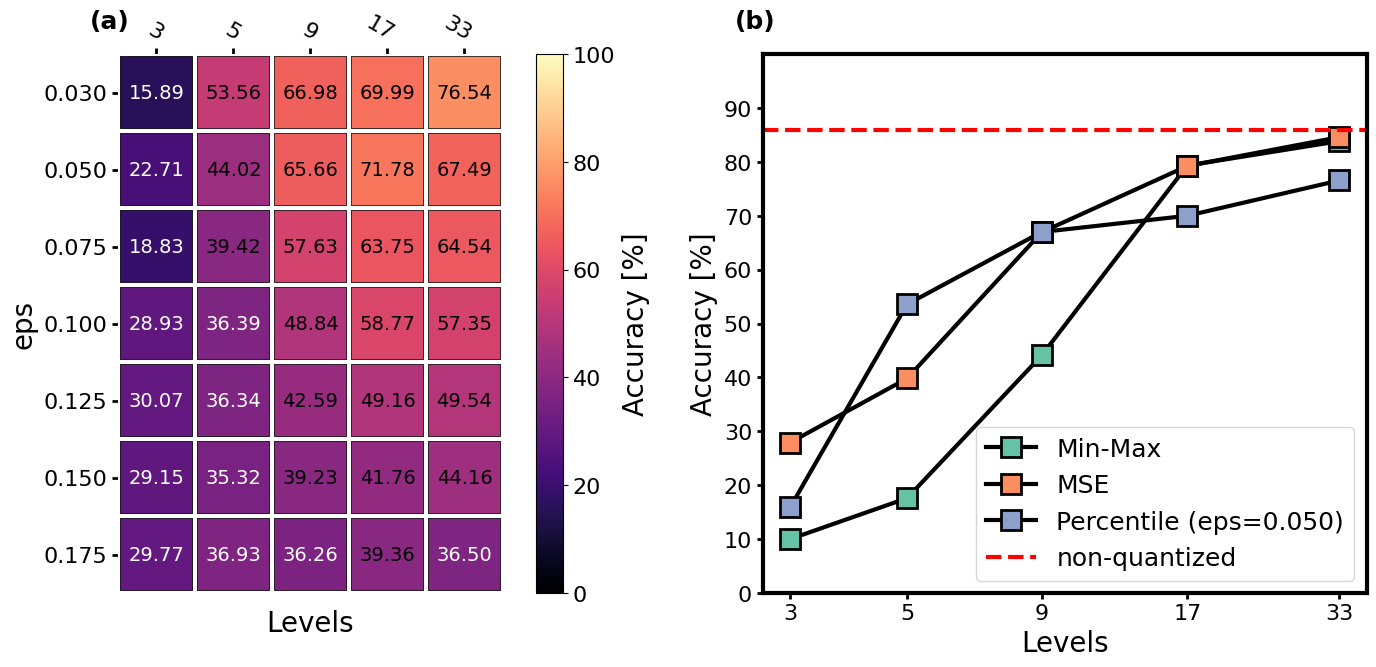

In [17]:
# =========================================================================================

fig, axs = plt.subplot_mosaic([["heatmap", "comparison"]], figsize=(18, 7), gridspec_kw={"width_ratios": [1.1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results1["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs["heatmap"], cmap = "magma", aspect = "equal", cbarlabel = "Accuracy [%]", title = "Percentile calibration (personally trained)")
cbar.ax.tick_params(labelsize = 16)
texts = annotate_heatmap(im, valfmt = "{x:.2f}")
# add x and y labels
axs["heatmap"].set_xlabel("Levels", fontdict = {"fontsize": 20})
axs["heatmap"].set_ylabel("eps", fontdict = {"fontsize": 20})

# The second plot shows the comparison between the different calibration methods
data1 = np.array([ results1["max"], results1["mse"], results1["percentile"][best_eps_index1, :]])
x = LEVELS

print(data1[0])
print(data1[1])
print(data1[2])

colors = matplotlib.colormaps["Set2"].colors
axs["comparison"].plot(x, data1[0], label = "Min-Max", marker = "s", markerfacecolor = colors[0], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)
axs["comparison"].plot(x, data1[1], label = "MSE", marker = "s", markerfacecolor = colors[1], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)
axs["comparison"].plot(x, data1[2], label = f"Percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k", markersize = 15, markeredgewidth = 2, linewidth = 3)

axs["comparison"].set_xscale("log", base = 2)
axs["comparison"].set_xticks(x)
axs["comparison"].set_xticklabels([str(levels) for levels in x])
axs["comparison"].set_ylim(0, 100)
axs["comparison"].set_yticks(np.arange(0, 100 , 10.0))
# axs["comparison"].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
#increase the size of the ticks
axs["comparison"].tick_params(axis = "both", which = "both", length = 4, width = 3)
axs["comparison"].axhline(y = results1["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 3)


# axs["comparison"].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
# axs["comparison"].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs["comparison"].legend()
axs["comparison"].set_xlabel("Levels", fontdict = {"fontsize": 20})
axs["comparison"].set_ylabel("Accuracy [%]", fontdict = {"fontsize": 20})
axs["comparison"].set_yticks(np.arange(0, 100 , 10.0))
axs["comparison"].set_ylim(0, 100)
# axs["comparison"].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})

# increase the ticks label size
axs["heatmap"].tick_params(axis = "both", which = "major", labelsize = 16)
axs["comparison"].tick_params(axis = "both", which = "major", labelsize = 16)
# make the axis border for the second plot thicker
axs["comparison"].spines["top"].set_linewidth(3)
axs["comparison"].spines["right"].set_linewidth(3)
axs["comparison"].spines["bottom"].set_linewidth(3)
axs["comparison"].spines["left"].set_linewidth(3)
# increase the thickness of the ticks
axs["comparison"].tick_params(width = 2)
axs["heatmap"].tick_params(width = 2)

# make the legend bigger
axs["comparison"].legend(fontsize = 18)

# set a and b labels
for label, ax in axs.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    ax.text(
        0.0, 1.0, "(a)" if label=="heatmap" else "(b)", transform=(
            ax.transAxes + ScaledTranslation(-20/72, 15/72, fig.dpi_scale_trans)),
        fontsize=18, va='bottom', fontweight='bold')



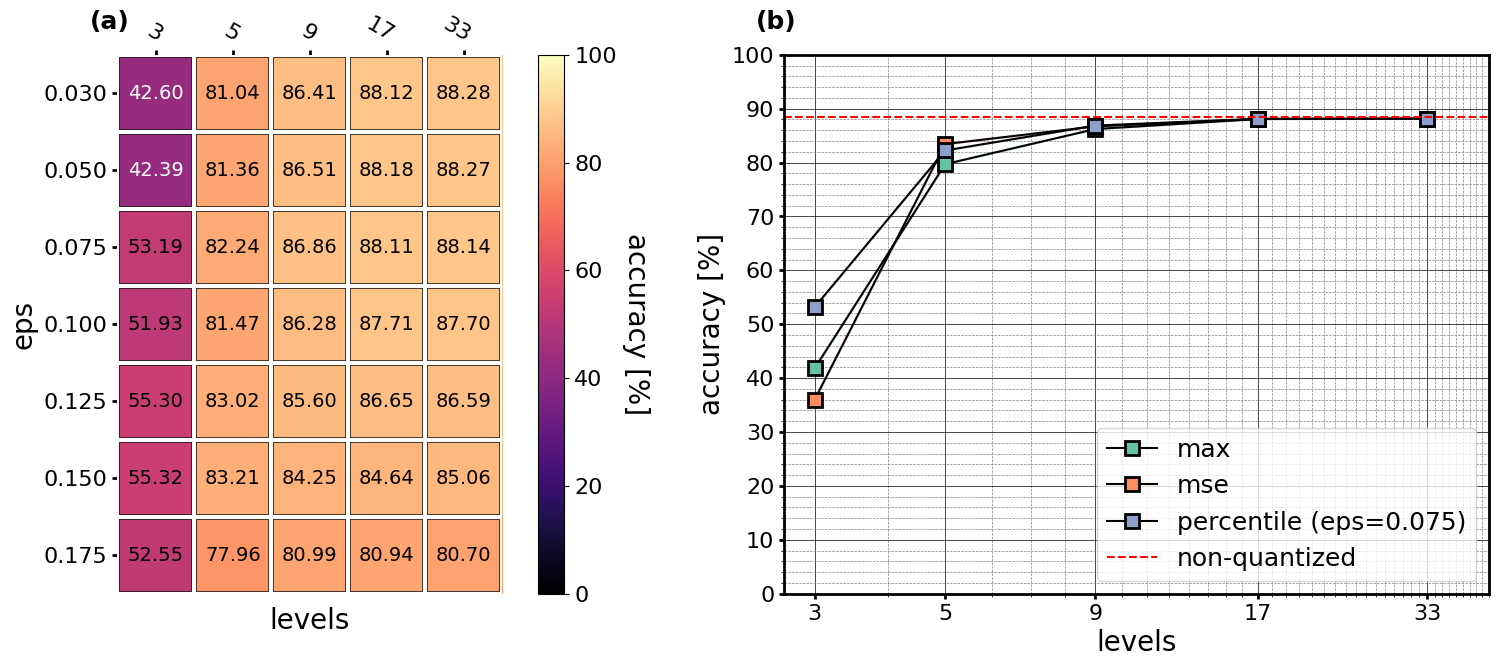

In [63]:
fig, axs = plt.subplot_mosaic([["heatmap", "comparison"]], figsize=(20, 7), gridspec_kw={"width_ratios": [1, 1]})

im, cbar = heatmap( results2["percentile"], row_labels = xlabs, col_labels = ylabs,
                     ax = axs["heatmap"], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration (aihwkit trained)")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")
cbar.ax.tick_params(labelsize = 16)
# add x and y labels
axs["heatmap"].set_xlabel("levels", fontdict = {"fontsize": 20})
axs["heatmap"].set_ylabel("eps", fontdict = {"fontsize": 20})

data2 = np.array([ results2["max"], results2["mse"], results2["percentile"][best_eps_index2, :]])

axs["comparison"].plot(x, data2[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k", markersize = 10, markeredgewidth = 2)
axs["comparison"].fill_between(x, data2[0] - 2*results2["max_std"], data2[0] + 2*results2["max_std"], alpha = 0.4, color = colors[0])
axs["comparison"].plot(x, data2[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k", markersize = 10, markeredgewidth = 2)
axs["comparison"].fill_between(x, data2[1] - 2*results2["mse_std"], data2[1] + 2*results2["mse_std"], alpha = 0.4, color = colors[1])
axs["comparison"].plot(x, data2[2], label = f"percentile (eps={best_eps2:.3f})", marker = "s", markerfacecolor = colors[2], color = "k", markersize = 10, markeredgewidth = 2)
axs["comparison"].fill_between(x, data2[2] - 2*results2["percentile_std"][best_eps_index2], data2[2] + 2*results2["percentile_std"][best_eps_index2], alpha = 0.4, color = colors[2])
axs["comparison"].set_xscale("log", base = 2)
axs["comparison"].set_ylim(0, 100)
axs["comparison"].set_xticks(x)
axs["comparison"].set_xticklabels([str(levels) for levels in x])
axs["comparison"].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs["comparison"].xaxis.set_minor_formatter(plt.NullFormatter())
axs["comparison"].set_yticks(np.arange(0, 100 , 2.0), minor = True)
axs["comparison"].axhline(y = results2["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)

axs["comparison"].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs["comparison"].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs["comparison"].legend()
axs["comparison"].set_xlabel("levels", fontdict = {"fontsize":20})
axs["comparison"].set_ylabel("accuracy [%]", fontdict = {"fontsize": 20})
# axs[1,1].set_title("Comparison of calibration methods (aihwkit trained)", fontdict = {"fontsize": 14})
# increase the ticks label size
axs["heatmap"].tick_params(axis = "both", which = "major", labelsize = 16)
axs["comparison"].tick_params(axis = "both", which = "major", labelsize = 16)
# make the axis border for the second plot thicker
axs["comparison"].spines["top"].set_linewidth(2)
axs["comparison"].spines["right"].set_linewidth(2)
axs["comparison"].spines["bottom"].set_linewidth(2)
axs["comparison"].spines["left"].set_linewidth(2)
# increase the thickness of the ticks
axs["comparison"].tick_params(width = 2)
axs["heatmap"].tick_params(width = 2)
# for the comparison, require majors ticks each 10
axs["comparison"].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
axs["comparison"].legend(fontsize = 18, loc = "lower right")

# set a and b labels
for label, ax in axs.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    ax.text(
        0.0, 1.0, "(a)" if label=="heatmap" else "(b)", transform=(
            ax.transAxes + ScaledTranslation(-20/72, 15/72, fig.dpi_scale_trans)),
        fontsize=18, va='bottom', fontweight='bold')

## Influence of the drift non-idealities
---

After benchmarking the ResNet9s for the different calibration methods, we would like to see how those methods are influenced by the drift non-idealities. We will use the same model and dataset as before, but this time, before performing the inference, we will first program the weights to the chosen drift noise, and then perform the inference. We will then compare the results.


In [5]:

from shared import resnet9s, CustomDefinedPreset, IdealPreset
from aihwkit.inference.converter.conductance import SinglePairConductanceConverter
src = os.getcwd()
src = os.path.abspath(os.path.join(src, '/../src'))
sys.path.append(src)

import src.plotting as pl
from src.utilities import interpolate
from src.noise import NullNoiseModel, ExperimentalNoiseModel, JustMedianNoiseModel, JustStdNoiseModel, InterpolatedNoiseModel

# extract the noise data
variables = interpolate(levels=3, file_path=cur_dir + "/../data/matlab/4bit.mat", force_interpolation=True)
noise_types = variables['str']

In [ ]:
#
# =========================================================================================
#                          EVALUATION OF PERSONALLY TRAINED RESNET9 
# =========================================================================================

TIMES = 10

_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

RPU_DEF = IdealPreset()

# Stardard model trained on FloatingPointRPUConfig
RESULTS_NON_QUANTIZED = cur_dir + "/resnet9_results"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9.th"), map_location=DEVICE)

accuracy_non_quantized = np.zeros((len(noise_types),TIMES))
for j,noise in enumerate(noise_types):

    noise_model = InterpolatedNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    degs = 1,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))
    rpu_config = deepcopy(RPU_DEF)
    rpu_config.noise_model = noise_model

    for t in range(TIMES):
        # dataloader = Sampler(validation_data, DEVICE)
        model = create_analog_network(FloatingPointRPUConfig()).to(DEVICE)
        model.load_state_dict(state_dict, strict=False, load_rpu_config=False)
        model = convert_to_digital(model)
        non_quantized_model = convert_to_analog(model, rpu_config)
        non_quantized_model.eval()
        non_quantized_model.program_analog_weights()
        # calibrate_input_ranges(
        #                     model=non_quantized_model,
        #                     calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
        #                     dataloader=dataloader,
        #                     )
        
        # del dataloader

        _, _, _, accuracy_non_quantized[j, t] = test_evaluation(validation_data, non_quantized_model, criterion)
        del non_quantized_model

    print(f"Accuracy of the non-quantized model (aihwkit trained) for noise {noise}: {accuracy_non_quantized[j,:].mean():.2f}%")
accuracy_non_quantized_std = accuracy_non_quantized.std(axis=1)
accuracy_non_quantized = accuracy_non_quantized.mean(axis=1)


torch.cuda.empty_cache()
# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(LEVELS), len(noise_types), TIMES))
eps = 0.03
for i, levels in enumerate(LEVELS):
    for j,noise in enumerate(noise_types):

            noise_model = ExperimentalNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    levels = levels,
                                                                    force_interpolation = True,
                                                                    compensation = False,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))
            rpu_config = deepcopy(RPU_DEF)
            quantization = WeightQuantizerParameter(
                eps= eps,
                levels = levels,
                method = "percentile"
            )
            rpu_config.quantization = quantization
            rpu_config.noise_model = noise_model
            
            for k in range(TIMES):
                
                model = create_analog_network(FloatingPointRPUConfig()).to(DEVICE)
                model.load_state_dict(state_dict, strict=False, load_rpu_config=False)
                model = convert_to_digital(model)
                quantized_model = convert_to_analog(model, rpu_config)
                quantized_model.eval()
                quantized_model.program_analog_weights()

                if (k == 0 and i == 0 and j == 0):
                    # plot the weights of the tiles
                    pl.generate_moving_hist(quantized_model, title = "percentile", file_name = "./test/weights_percentile_prog_own.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)

                _, _, _, accuracies_percentile[i, j, k] = test_evaluation(validation_data, quantized_model, criterion)
                
                del model
                del quantized_model
                torch.cuda.empty_cache()
            print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {np.mean(accuracies_percentile[i, j, :]):.2f}%")
accuracies_percentile_std = accuracies_percentile.std(axis=2)
accuracies_percentile = accuracies_percentile.mean(axis=2)

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros((len(LEVELS), len(noise_types), TIMES))
for i, levels in enumerate(LEVELS):
    for j,noise in enumerate(noise_types):

            noise_model = ExperimentalNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    levels = levels,
                                                                    force_interpolation = True,
                                                                    compensation = False,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))
            rpu_config = deepcopy(RPU_DEF)
            quantization = WeightQuantizerParameter(
                levels = levels,
                method = "max"
            )
            rpu_config.quantization = quantization
            rpu_config.noise_model = noise_model

            for k in range(TIMES):

                model = create_analog_network(FloatingPointRPUConfig()).to(DEVICE)
                model.load_state_dict(state_dict, strict=False, load_rpu_config=False)
                model = convert_to_digital(model)
                quantized_model = convert_to_analog(model, rpu_config)
                quantized_model.eval()
                quantized_model.program_analog_weights()

                _, _, _, accuracies_max[i,j,k] = test_evaluation(validation_data, quantized_model, criterion)
                if (k == 0 and i == 0 and j == 0):
                    # plot the weights of the tiles
                    pl.generate_moving_hist(quantized_model, title = "max", file_name = "./test/weights_max_prog_own.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)

                del model
                del quantized_model
                torch.cuda.empty_cache()
            print(f"Accuracy of the max model with levels={levels}: {np.mean(accuracies_max[i,j,:]):.2f}%")
accuracies_max_std = accuracies_max.std(axis=2)
accuracies_max = accuracies_max.mean(axis=2)
                

                
                

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros((len(LEVELS), len(noise_types), TIMES))
for i, levels in enumerate(LEVELS):
    for j,noise in enumerate(noise_types):

            noise_model = ExperimentalNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    levels = levels,
                                                                    force_interpolation = True,
                                                                    compensation = False,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))
            rpu_config = deepcopy(RPU_DEF)
            rpu_config.quantization = WeightQuantizerParameter(
                levels = levels,
                method = "mse"
            )
            rpu_config.quantization = quantization
            rpu_config.noise_model = noise_model

            for k in range(TIMES):
                
                model = create_analog_network(FloatingPointRPUConfig()).to(DEVICE)
                model.load_state_dict(state_dict, strict=False, load_rpu_config=False)
                model = convert_to_digital(model)
                quantized_model = convert_to_analog(model, rpu_config)
                quantized_model.eval()
                quantized_model.program_analog_weights()

                if (k == 0 and i == 0 and j == 0):
                    # plot the weights of the tiles
                    pl.generate_moving_hist(quantized_model, title = "mse", file_name = "./test/weights_mse_prog_own.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)

                _, _, _, accuracies_mse[i,j,k] = test_evaluation(validation_data, quantized_model, criterion)
                
                del model
                del quantized_model
                torch.cuda.empty_cache()
            print(f"Accuracy of the mse model with levels={levels}: {np.mean(accuracies_mse[i,j,:]):.2f}%")
accuracies_mse_std = accuracies_mse.std(axis=2)
accuracies_mse = accuracies_mse.mean(axis=2)

# Save the results
results_noise = {
    "percentile": accuracies_percentile,
    "percentile_std": accuracies_percentile_std,
    "max": accuracies_max,
    "max_std": accuracies_max_std,
    "mse": accuracies_mse,
    "mse_std": accuracies_mse_std,
}


torch.save(results_noise, os.path.join(DUMP_DIR, "results_resnet9s_own_noise.th"))

Files already downloaded and verified
Files already downloaded and verified




































































































































































































































































Accuracy of the non-quantized model (aihwkit trained) for noise Prog: 40.70%




































































































































































































































































Accuracy of the non-quantized model (aihwkit trained) for noise 1d,RT: 21.37%



























































































































































































































































In [ ]:
#
# =========================================================================================
#                          EVALUATION OF AIHWKIT TRAINED RESNET9
# =========================================================================================
#

from resnet import get_test_loader
from aihwkit.inference.calibration import (
    calibrate_input_ranges,
    InputRangeCalibrationType,
)

TIMES = 10

# Sampler class to use for input calibration
class Sampler:
    """Example of a sampler used for calibration."""

    def __init__(self, loader, device):
        self.device = device
        self.loader = iter(loader)
        self.idx = 0

    def __iter__(self):
        return self

    def __next__(self):
        x, _ = next(self.loader)
        self.idx += 1
        if self.idx > 100:
            raise StopIteration

        return ([x.to(self.device)], {})

# Load datasets.
validation_data = get_test_loader()
criterion = nn.CrossEntropyLoss()


# rpu_config = FloatingPointRPUConfig()
RPU_DEF = IdealPreset()

# aihwkit model, trained on StandardHWATrainingPreset
RESULTS_NON_QUANTIZED = cur_dir + "/../resnet"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9s.th"), map_location=DEVICE)

accuracy_non_quantized = np.zeros((len(noise_types),TIMES))
for j,noise in enumerate(noise_types):

    noise_model = InterpolatedNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    degs = 1,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))
    rpu_config = deepcopy(RPU_DEF)
    rpu_config.noise_model = noise_model

    for t in range(TIMES):
        # dataloader = Sampler(validation_data, DEVICE)
        model = resnet9s().to(DEVICE)    
        model.load_state_dict(state_dict["model_state_dict"], strict=True)
        
        non_quantized_model = convert_to_analog(model, rpu_config)
        non_quantized_model.eval()
        non_quantized_model.program_analog_weights()
        # calibrate_input_ranges(
        #                     model=non_quantized_model,
        #                     calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
        #                     dataloader=dataloader,
        #                     )
        
        # del dataloader

        _, _, _, accuracy_non_quantized[j, t] = test_evaluation(validation_data, non_quantized_model, criterion)
        del non_quantized_model

    print(f"Accuracy of the non-quantized model (aihwkit trained) for noise {noise}: {accuracy_non_quantized[j,:].mean():.2f}%")
accuracy_non_quantized_std = accuracy_non_quantized.std(axis=1)
accuracy_non_quantized = accuracy_non_quantized.mean(axis=1)


# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(LEVELS), len(noise_types), TIMES))
eps = 0.075

for i, levels in enumerate(LEVELS):
    for j,noise in enumerate(noise_types):

            noise_model = ExperimentalNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    levels = levels,
                                                                    force_interpolation = True,
                                                                    compensation = False,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))
            rpu_config = deepcopy(RPU_DEF)
            rpu_config.quantization = RPU_CONFIG_PERCENTILE.quantization
            rpu_config.quantization.eps = eps
            rpu_config.quantization.levels = levels
            rpu_config.noise_model = noise_model
            
            for k in range(TIMES):
                
                # dataloader = Sampler(validation_data, DEVICE)

                model = resnet9s().to(DEVICE)
                model.load_state_dict(state_dict["model_state_dict"], strict=True)
                quantized_model = convert_to_analog(model, rpu_config)
                # calibrate_input_ranges(
                #             model=quantized_model,
                #             calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                #             dataloader=dataloader,
                #             )
                quantized_model.eval()
                quantized_model.program_analog_weights()
                
                _, _, _, accuracies_percentile[i, j, k] = test_evaluation(validation_data, quantized_model, criterion)

                if (k == 0 and i == 0 and j == 0):
                    # plot the weights of the tiles
                    pl.generate_moving_hist(quantized_model, title = "percentile", file_name = "./test/weights_percetile_prog.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)
                
                del model
                del quantized_model
                # del dataloader
            print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j, :].mean():.2f}%")
accuracies_percentile_std = accuracies_percentile.std(axis=2)
accuracies_percentile = accuracies_percentile.mean(axis=2)


# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros((len(LEVELS), len(noise_types), TIMES))
for i, levels in enumerate(LEVELS):
    for j,noise in enumerate(noise_types):

            noise_model = ExperimentalNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                    type = noise,
                                                                    levels = levels,
                                                                    force_interpolation = True,
                                                                    compensation = False,
                                                                    g_converter=SinglePairConductanceConverter(g_max=40.))

            rpu_config = deepcopy(RPU_DEF)
            rpu_config.quantization = RPU_CONFIG_MAX.quantization
            rpu_config.quantization.levels = levels
            rpu_config.noise_model = noise_model

            for k in range(TIMES):
                # dataloader = Sampler(validation_data, DEVICE)

                model = resnet9s().to(DEVICE)
                model.load_state_dict(state_dict["model_state_dict"], strict=True)
                quantized_model = convert_to_analog(model, rpu_config)
                # calibrate_input_ranges(
                #             model=quantized_model,
                #             calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                #             dataloader=dataloader,
                #             )
                quantized_model.eval()
                quantized_model.program_analog_weights()

                if (k == 0 and i == 0 and j == 0):
                    # plot the weights of the tiles
                    pl.generate_moving_hist(quantized_model, title = "max", file_name = "./test/weights_max_prog.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)

                _, _, _, accuracies_max[i,j,k] = test_evaluation(validation_data, quantized_model, criterion)
                del model
                del quantized_model
                # del dataloader

    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[i, j, :].mean():.2f}%")
accuracies_max_std = accuracies_max.std(axis=2)
accuracies_max = accuracies_max.mean(axis=2)


# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros((len(LEVELS), len(noise_types), TIMES))
for i, levels in enumerate(LEVELS):
    for j,noise in enumerate(noise_types):

        noise_model = ExperimentalNoiseModel(file_path = cur_dir + "/../data/matlab/4bit.mat",
                                                                type = noise,
                                                                levels = levels,
                                                                force_interpolation = True,
                                                                compensation = False,
                                                                g_converter=SinglePairConductanceConverter(g_max=40.))

        
        rpu_config = deepcopy(RPU_DEF)
        rpu_config.quantization = RPU_CONFIG_MSE.quantization
        rpu_config.quantization.levels = levels
        rpu_config.noise_model = noise_model
    
        for k in range(TIMES):
            # dataloader = Sampler(validation_data, DEVICE)

            model = resnet9s().to(DEVICE)
            model.load_state_dict(state_dict["model_state_dict"], strict=True)
            quantized_model = convert_to_analog(model, rpu_config)
            # calibrate_input_ranges(
            #             model=quantized_model,
            #             calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
            #             dataloader=dataloader,
            #             )
            quantized_model.eval()
            quantized_model.program_analog_weights()

            if (k == 0 and i == 0 and j == 0):
                # plot the weights of the tiles
                pl.generate_moving_hist(quantized_model, title = "mse", file_name = "./test/weights_mse_prog.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)

            _, _, _, accuracies_mse[i,j,k] = test_evaluation(validation_data, quantized_model, criterion)
            del model
            del quantized_model
            # del dataloader
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[i,j, :].mean():.2f}%")
accuracies_mse_std = accuracies_mse.std(axis=2)
accuracies_mse = accuracies_mse.mean(axis=2)


results = {
    "non_quantized": accuracy_non_quantized,
    "non_quantized_std": accuracy_non_quantized_std,
    "percentile": accuracies_percentile,
    "percentile_std": accuracies_percentile_std,
    "max": accuracies_max,
    "max_std": accuracies_max_std,
    "mse": accuracies_mse,
    "mse_std": accuracies_mse_std,
}


torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_aihwkit_noise.th"))

Files already downloaded and verified




































































































































































































































































Accuracy of the non-quantized model (aihwkit trained) for noise Prog: 85.78%




































































































































































































































































Accuracy of the non-quantized model (aihwkit trained) for noise 1d,RT: 73.97%




































































































































































































































































Accuracy of the non-quantiz

In [3]:
results1 = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_own_noise.th"))
results2 = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit_noise.th"))

print("Shape of results1: ", results1.keys())
print("Shape of results2: ", results2.keys())



Shape of results1:  dict_keys(['non_quantized', 'non_quantized_std', 'percentile', 'percentile_std', 'max', 'max_std', 'mse', 'mse_std'])
Shape of results2:  dict_keys(['non_quantized', 'non_quantized_std', 'percentile', 'percentile_std', 'max', 'max_std', 'mse', 'mse_std'])


88.39


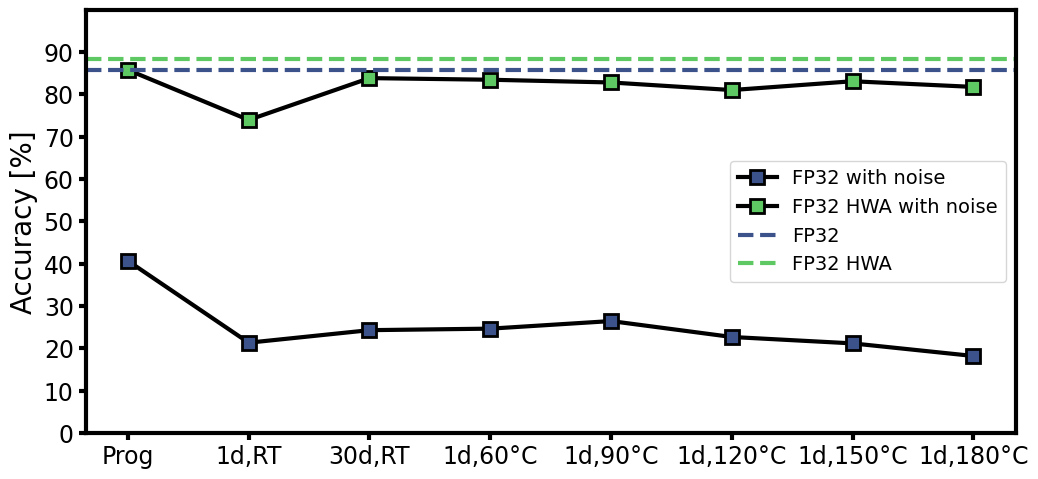

In [6]:
results  = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_own.th"))
results_a = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit_ideal.th"))
results0  = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit_noise.th"))

own_non_quantized_ideal = results["non_quantized"]
own_non_quantized_noise = results1["non_quantized"]

aihwkit_non_quantized_ideal = results_a["non_quantized"]
aihwkit_non_quantized_noise = results0["non_quantized"]
print(aihwkit_non_quantized_ideal)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(LEVELS)))
# markers = ["o", "s", "D", "v", "^"]

# plot how the accuracy of Resnet changes with noise
fig, axs = plt.subplots(1, 1, figsize=(12, 5.5))
axs.plot(noise_types, own_non_quantized_noise, label = "FP32 with noise", marker = "s", markerfacecolor = colors[1], markeredgecolor = "k", markersize = 10, markeredgewidth = 2, color = "k", linewidth = 3)
axs.plot(noise_types, aihwkit_non_quantized_noise, label = "FP32 HWA with noise", marker = "s", markerfacecolor = colors[3], markeredgecolor = "k", markersize = 10, markeredgewidth = 2, color = "k", linewidth = 3)
# for each level, add the percentile quantized accuracy on the plot

# for i, levels in enumerate(LEVELS):
#     accuracies = results1["percentile"][i, :]
#     axs.plot(noise_types, accuracies, label = f"percentile (levels={levels})", marker = markers[i], color = colors[i], markersize = 10, markeredgewidth = 2)

axs.axhline(y = own_non_quantized_ideal, color = colors[1], linestyle = "--", label = "FP32", linewidth = 3)
axs.axhline(y = aihwkit_non_quantized_ideal, color = colors[3], linestyle = "--", label = "FP32 HWA", linewidth = 3)
# axs.grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs.set_yticks(np.arange(0, 100, 10.0),)
axs.set_ylim(0, 100)
# axs.grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs.legend(fontsize= 14)
# increase the size of the labels of the ticks
axs.tick_params(axis = "both", which = "major", labelsize = 17)
axs.set_ylabel("Accuracy [%]", fontdict = {"fontsize": 20})

# increase the thickness of the ticks
axs.tick_params(width = 3)
# make the axis border thicker
axs.spines["top"].set_linewidth(3)
axs.spines["right"].set_linewidth(3)
axs.spines["bottom"].set_linewidth(3)
axs.spines["left"].set_linewidth(3)
# increase the size of the ticks
axs.tick_params(width = 3, length = 5)


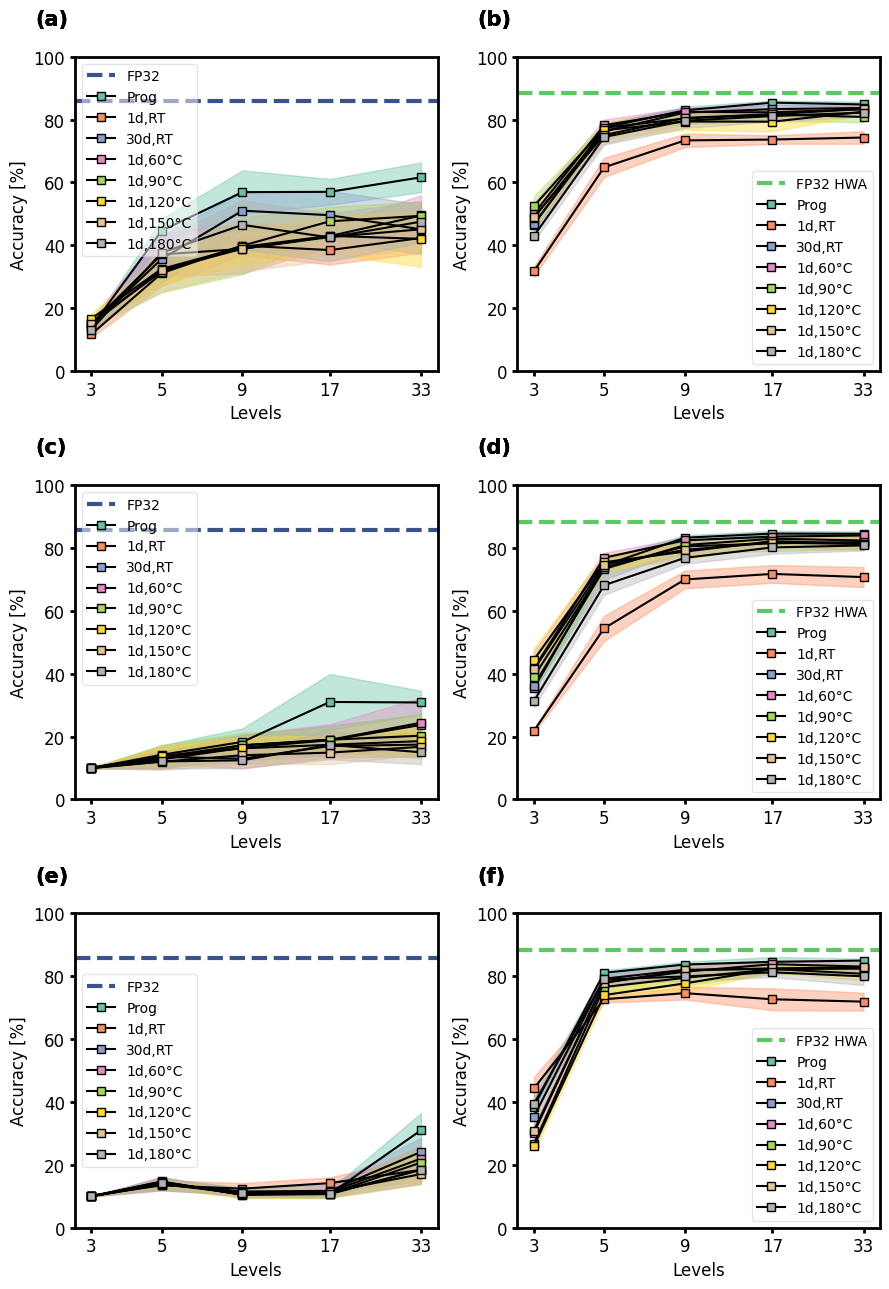

In [9]:
# extract the noise data
from shared import resnet9s, CustomDefinedPreset, IdealPreset
from matplotlib.transforms import ScaledTranslation
from aihwkit.inference.converter.conductance import SinglePairConductanceConverter
src = os.getcwd()
src = os.path.abspath(os.path.join(src, '/../src'))
sys.path.append(src)

import src.plotting as pl
from src.utilities import interpolate
from src.noise import NullNoiseModel, ExperimentalNoiseModel, JustMedianNoiseModel, JustStdNoiseModel
variables = interpolate(levels=3, file_path=cur_dir + "/../data/matlab/4bit.mat", force_interpolation=True)
noise_types = variables['str']

fig, ax = plt.subplot_mosaic([["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"]], figsize=(9, 13))

# Two axes, one for each model (own and aihwkit):
# in each figure, for different levels (x axis), we plot the mean accuracy for each noise type.
# Each noise type will have its own colors, tacken from Set2 colormap.
colormap = plt.get_cmap("Set2")

CALIBRATIONS = ["percentile", "max", "mse"]
NOISES  = noise_types
x = LEVELS
for c, calib in enumerate(CALIBRATIONS):
    labels = ["(a)", "(c)", "(e)"]
    for n, noise in enumerate(NOISES):
        if n == 0:
            ax[labels[c]].axhline(y = own_non_quantized_ideal, color = colors[1], linestyle = "--", label = "FP32", linewidth = 3)
        color = colormap(n)
        ax[labels[c]].plot(LEVELS, results1[calib][:, n], label = noise, marker = "s", markerfacecolor = color, markeredgecolor = "k", color = "k")
        upper_bound = results1[calib][:, n] + results1[calib+"_std"][:, n]
        for up in  upper_bound:
            if up > 100:
                up = 100
        ax[labels[c]].fill_between(LEVELS, results1[calib][:, n] - results1[calib+"_std"][:, n], upper_bound, alpha = 0.4, color = color)
        # add the non-quantized accuracy
        
    
       
    ax[labels[c]].set_xscale("log", base = 2)
    ax[labels[c]].set_ylim(0, 100)
    ax[labels[c]].set_xticks(x)
    ax[labels[c]].set_xticklabels([str(levels) for levels in x])
    # ax[labels[c]].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
    # ax[labels[c]].xaxis.set_minor_formatter(plt.NullFormatter())
    ax[labels[c]].set_ylim(0, 100)
    # ax[labels[c]].axhline(y = results1["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)
    # ax[labels[c]].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
    # ax[labels[c]].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
    ax[labels[c]].legend(fancybox=True, framealpha=0.5)
    ax[labels[c]].set_xlabel("Levels", fontdict = {"fontsize": 12})
    ax[labels[c]].set_ylabel("Accuracy [%]", fontdict = {"fontsize": 12})
    # ax[labels[c]].set_title("{} calibration".format(calib), fontdict = {"fontsize": 14})

    #increase the size of the ticks
    ax[labels[c]].tick_params(axis = "both", which = "major", labelsize = 12)
    #increase the thickness of the ticks
    ax[labels[c]].tick_params(width = 2)
    #increase the thickness of the border
    ax[labels[c]].spines["top"].set_linewidth(2)
    ax[labels[c]].spines["right"].set_linewidth(2)
    ax[labels[c]].spines["bottom"].set_linewidth(2)
    ax[labels[c]].spines["left"].set_linewidth(2)

    labels = ["(b)", "(d)", "(f)"]
    for n, noise in enumerate(NOISES):
        if n == 0:
            ax[labels[c]].axhline(y = aihwkit_non_quantized_ideal, color = colors[3], linestyle = "--", label = "FP32 HWA", linewidth = 3)

        color = colormap(n)
        ax[labels[c]].plot(LEVELS, results2[calib][:, n], label = noise, marker = "s", markerfacecolor = color, markeredgecolor = "k", color = "k")
        upper_bound = results2[calib][:, n] + results2[calib+"_std"][:, n]
        for up in  upper_bound:
            if up > 100:
                up = 100
        ax[labels[c]].fill_between(LEVELS, results2[calib][:, n] - results2[calib+"_std"][:, n], upper_bound, alpha = 0.4, color = color)
        

    ax[labels[c]].set_xscale("log", base = 2)
    ax[labels[c]].set_ylim(0, 100)
    ax[labels[c]].set_xticks(x)
    ax[labels[c]].set_xticklabels([str(levels) for levels in x])
    # ax[labels[c]].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
    # ax[labels[c]].xaxis.set_minor_formatter(plt.NullFormatter())
    ax[labels[c]].set_ylim(0, 100)
    # ax[labels[c]].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
    # ax[labels[c]].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
    ax[labels[c]].legend(fancybox=True, framealpha=0.5)
    ax[labels[c]].set_xlabel("Levels", fontdict = {"fontsize": 12})
    ax[labels[c]].set_ylabel("Accuracy [%]", fontdict = {"fontsize": 12})
    # ax[labels[c]].set_title("{} calibration".format(calib), fontdict = {"fontsize": 14})

    #increase the size of the ticks
    ax[labels[c]].tick_params(axis = "both", which = "major", labelsize = 12)
    #increase the thickness of the ticks
    ax[labels[c]].tick_params(width = 2)
    #increase the thickness of the border
    ax[labels[c]].spines["top"].set_linewidth(2)
    ax[labels[c]].spines["right"].set_linewidth(2)
    ax[labels[c]].spines["bottom"].set_linewidth(2)
    ax[labels[c]].spines["left"].set_linewidth(2)

    #make the plot tight
    fig.tight_layout()

    for label, a in ax.items():
        # Use ScaledTranslation to put the label
        # - at the top left corner (axes fraction (0, 1)),
        # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
        # i.e. just outside the axes.
            a.text(
                0.0, 1.0, label, transform=(
                    a.transAxes + ScaledTranslation(-20/50, +20/72, fig.dpi_scale_trans)),
                fontsize=15, va='bottom', fontweight='bold')


46.589999999999996
31.722
46.846999999999994
50.083999999999996
52.488
48.73299999999999
49.132
42.981


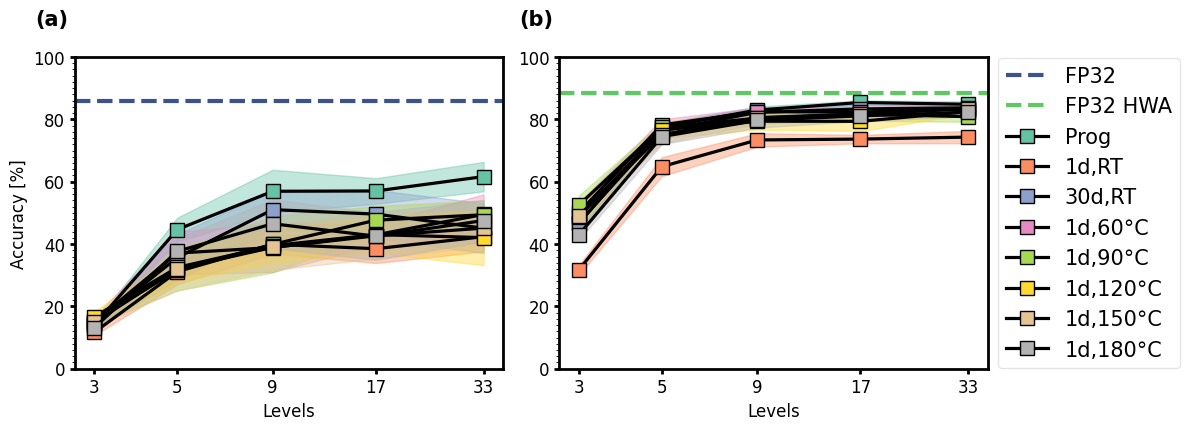

In [11]:
fig, ax = plt.subplot_mosaic([["(a)", "(b)"]], figsize=(12, 4))

# Two axes, one for each model (own and aihwkit):
# in each figure, for different levels (x axis), we plot the mean accuracy for each noise type.
# Each noise type will have its own colors, tacken from Set2 colormap.
colormap = plt.get_cmap("Set2")


CALIBRATIONS = ["percentile"]
NOISES  = noise_types
x = LEVELS
for c, calib in enumerate(CALIBRATIONS):
    labels = ["(a)"]
    ax[labels[c]].axhline(y = own_non_quantized_ideal, color = colors[1], linestyle = "--", label = "FP32", linewidth = 3)
    for n, noise in enumerate(NOISES):
        color = colormap(n)
        ax[labels[c]].plot(LEVELS, results1[calib][:, n], marker = "s", markerfacecolor = color, markeredgecolor = "k", color = "k", linewidth = 2.3, markersize = 10)
        upper_bound = results1[calib][:, n] + results1[calib+"_std"][:, n]
        for up in  upper_bound:
            if up > 100:
                up = 100
        ax[labels[c]].fill_between(LEVELS, results1[calib][:, n] - results1[calib+"_std"][:, n], upper_bound, alpha = 0.4, color = color)
    
       
    ax[labels[c]].set_xscale("log", base = 2)
    ax[labels[c]].set_ylim(0, 100)
    ax[labels[c]].set_xticks(x)
    ax[labels[c]].set_xticklabels([str(levels) for levels in x])
    # ax[labels[c]].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
    # ax[labels[c]].xaxis.set_minor_formatter(plt.NullFormatter())
    ax[labels[c]].set_yticks(np.arange(0, 100 , 2.0), minor = True)
    # ax[labels[c]].axhline(y = results1["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)
    # ax[labels[c]].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
    # ax[labels[c]].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
    #ax[labels[c]].legend(fontsize = 12)
    ax[labels[c]].set_xlabel("Levels", fontdict = {"fontsize": 12})
    ax[labels[c]].set_ylabel("Accuracy [%]", fontdict = {"fontsize": 12})

    #increase the size of the ticks
    ax[labels[c]].tick_params(axis = "both", which = "major", labelsize = 12)
    #increase the thickness of the ticks
    ax[labels[c]].tick_params(width = 2)
    #increase the thickness of the border
    ax[labels[c]].spines["top"].set_linewidth(2)
    ax[labels[c]].spines["right"].set_linewidth(2)
    ax[labels[c]].spines["bottom"].set_linewidth(2)
    ax[labels[c]].spines["left"].set_linewidth(2)

    labels = ["(b)"]
    ax[labels[c]].axhline(y = aihwkit_non_quantized_ideal, color = colors[3], linestyle = "--", label = "FP32 HWA", linewidth = 3)
    

    for n, noise in enumerate(NOISES):
            
        color = colormap(n)
        print(results2[calib][0, n])
        ax[labels[c]].plot(LEVELS, results2[calib][:, n], label = noise, marker = "s", markerfacecolor = color, markeredgecolor = "k", color = "k", linewidth = 2.3, markersize = 10)
        upper_bound = results2[calib][:, n] + results2[calib+"_std"][:, n]
        for up in  upper_bound:
            if up > 100:
                up = 100
        ax[labels[c]].fill_between(LEVELS, results2[calib][:, n] - results2[calib+"_std"][:, n], upper_bound, alpha = 0.4, color = color)
        # ax[labels[c]].axhline(y = results2["non_quantized"][n], color = color, linestyle = "--", linewidth = 1.5)

    ax[labels[c]].set_xscale("log", base = 2)
    ax[labels[c]].set_ylim(0, 100)
    ax[labels[c]].set_xticks(x)
    ax[labels[c]].set_xticklabels([str(levels) for levels in x])
    # ax[labels[c]].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
    ax[labels[c]].xaxis.set_minor_formatter(plt.NullFormatter())
    ax[labels[c]].set_yticks(np.arange(0, 100 , 2.0), minor = True)
    # ax[labels[c]].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
    # ax[labels[c]].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
    ax[labels[c]].legend(fontsize = 12, fancybox=True, framealpha=0.5)
    ax[labels[c]].set_xlabel("Levels", fontdict = {"fontsize": 12})
    # ax[labels[c]].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})

    #increase the size of the ticks
    ax[labels[c]].tick_params(axis = "both", which = "major", labelsize = 12)
    #increase the thickness of the ticks
    ax[labels[c]].tick_params(width = 2)
    #increase the thickness of the border
    ax[labels[c]].spines["top"].set_linewidth(2)
    ax[labels[c]].spines["right"].set_linewidth(2)
    ax[labels[c]].spines["bottom"].set_linewidth(2)
    ax[labels[c]].spines["left"].set_linewidth(2)

    # also add the non-quantized accuracy from the other plot the the legend
    #move the legend out of the plot
    handles, lab = ax[labels[c]].get_legend_handles_labels()
    ax[labels[c]].legend(handles = [ax["(a)"].get_lines()[0]]+handles , labels =  ["FP32"]+lab, fancybox=True, framealpha=0.5, loc = "center left", bbox_to_anchor=(1, 0.5) , fontsize = 15)
    

    #make the plot tight
    fig.tight_layout()

    for label, a in ax.items():
        # Use ScaledTranslation to put the label
        # - at the top left corner (axes fraction (0, 1)),
        # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
        # i.e. just outside the axes.
        if label == "(a)" or label == "(b)":
            
            a.text(
                0.0, 1.0, label, transform=(
                    a.transAxes + ScaledTranslation(-20/50, +20/72, fig.dpi_scale_trans)),
                fontsize=15, va='bottom', fontweight='bold')


### Pytorch Resnet9s model
In this section, a resnet9s model, same as the other ones, is trained in pure pytorch, then loaded and quantization is performed using the different calibrations. We then compare the results with the other models previously quantized.

In [9]:
# the model is already trained and saved in the "resnet9_base_results" folder
PYTORCH_MODEL_PATH = cur_dir + "/resnet9_base_results/resnet9_base.th"

from shared import resnet9s

_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()
model = resnet9s().to(DEVICE)
model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
model.eval()
accuracy_pytorch = test_evaluation(validation_data, model, criterion)[3]
print(accuracy_pytorch)

Files already downloaded and verified
Files already downloaded and verified
86.75


In [10]:


#
# =========================================================================================
#                          EVALUATION OF PYTORCH TRAINED RESNET9
# =========================================================================================
#

_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

rpu_config = FloatingPointRPUConfig()

rpu_config = FloatingPointRPUConfig()
# Load the model
non_quantized_model = resnet9s().to(DEVICE)
non_quantized_model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
non_quantized_model = convert_to_analog(non_quantized_model, rpu_config)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model (personally trained): {accuracy_non_quantized:.2f}%")

# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = resnet9s().to(DEVICE)
        model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
        quantized_model = convert_to_analog(model, rpu_config)
        quantized_model.eval()

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = resnet9s().to(DEVICE)
    model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = resnet9s().to(DEVICE)
    model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_pytorch.th"))



Files already downloaded and verified
Files already downloaded and verified
Accuracy of the non-quantized model (personally trained): 86.74%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 32.68%
Accuracy of the percentile model with eps=0.030 and levels=5: 52.70%
Accuracy of the percentile model with eps=0.030 and levels=9: 76.73%
Accuracy of the percentile model with eps=0.030 and levels=17: 78.50%
Accuracy of the percentile model with eps=0.030 and levels=33: 79.70%
Accuracy of the percentile model with eps=0.050 and levels=3: 42.39%
Accuracy of the percentile model with eps=0.050 and levels=5: 55.79%
Accuracy of the percentile model with eps=0.050 and levels=9: 65.79%
Accuracy of the percentile model with eps=0.050 and levels=17: 75.36%
Accuracy of the percentile model with eps=0.050 and levels=33: 70.72%
Accuracy of the percentile model with eps=0.075 and levels=3: 32.74%
Accuracy of the percentile model with

In [ ]:


# Load the results


# results = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit.th"))
results = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_pytorch.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile = results["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index = mean_accuracy_percentile.argmax()
best_eps = EPS[best_eps_index]
print(f"Best eps: {best_eps}")


Best eps: 0.075


Text(0.5, 1.0, 'Comparison of calibration methods')

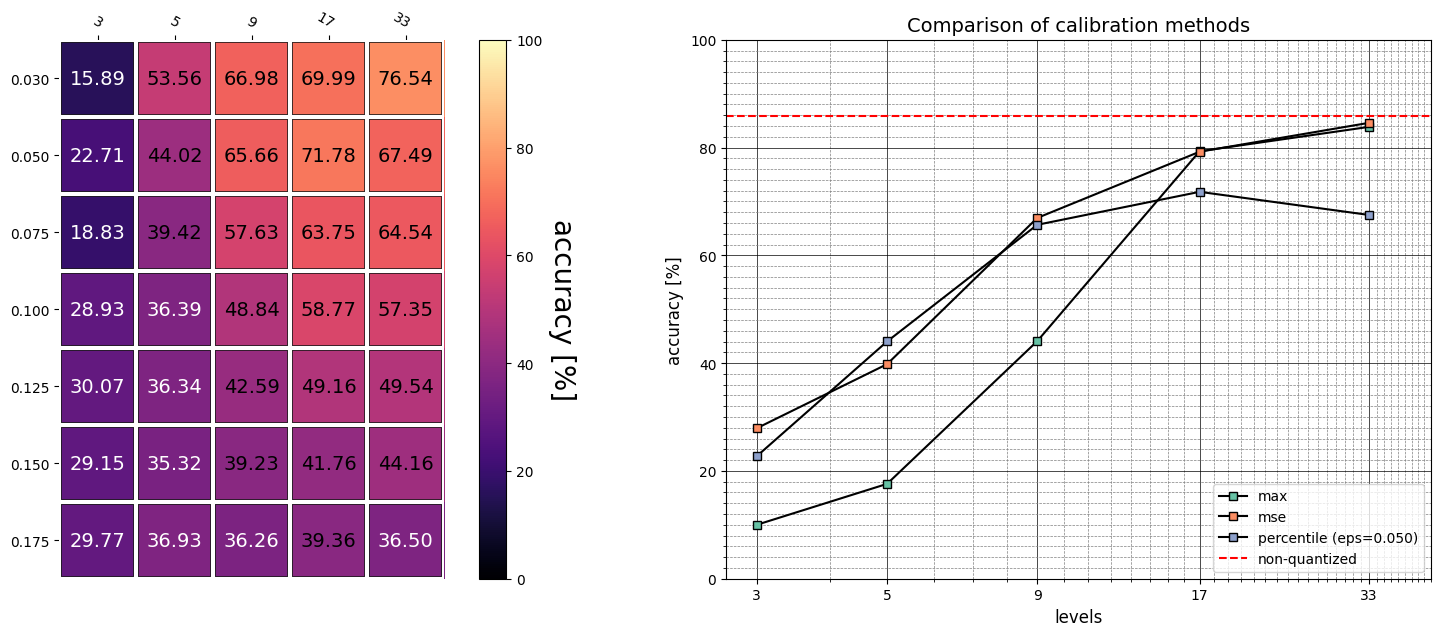

In [61]:
# =========================================================================================

fig, axs = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs[0], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")

# The second plot shows the comparison between the different calibration methods
data = np.array([ results["max"], results["mse"], results["percentile"][best_eps_index, :]])
x = LEVELS


colors = matplotlib.colormaps["Set2"].colors
axs[1].plot(x, data[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k")
axs[1].plot(x, data[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k")
axs[1].plot(x, data[2], label = f"percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k")
axs[1].set_ylim(0, 100)
axs[1].set_xscale("log", base = 2)
axs[1].set_xticks(x)
axs[1].set_xticklabels([str(levels) for levels in x])
axs[1].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs[1].xaxis.set_minor_formatter(plt.NullFormatter())
axs[1].set_yticks(np.arange(0, 100, 2.0), minor = True)
axs[1].axhline(y = results["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)


axs[1].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs[1].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs[1].legend()
axs[1].set_xlabel("levels", fontdict = {"fontsize": 12})
axs[1].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})
axs[1].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})